# 🐾 Pet Image Classification — CNN from Scratch

**Model:** `Input(3072) → FC(512) → ReLU → Dropout → FC(256) → ReLU → Dropout → FC(10) → Softmax`  
**Dataset:** 10 pet breeds · 1 500 images · 32×32 RGB (synthetic, no download needed)  
**Backend:** NumPy + scikit-learn only — no PyTorch / TensorFlow required

---
| Section | Content |
|---|---|
| 1 | Imports & Setup |
| 2 | Dataset Generation |
| 3 | EDA & Visualisations |
| 4 | Neural Network Architecture |
| 5 | Training Loop |
| 6 | Evaluation & Results |
| 7 | Plots |

## 📦 Section 1 — Imports & Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor':  '#161b22',
    'axes.edgecolor':   '#30363d', 'text.color':      '#e6edf3',
    'axes.labelcolor':  '#e6edf3', 'xtick.color':     '#8b949e',
    'ytick.color':      '#8b949e', 'grid.color':      '#21262d',
    'grid.alpha': 0.8,  'font.size': 11,
})

np.random.seed(42)
print('✅ Imports successful!')

✅ Imports successful!


## 🗂️ Section 2 — Dataset Generation

We generate **1 500 synthetic 32×32 RGB pet images** across 10 breeds.  
Each class has a unique colour signature, texture pattern, and noise level so the network must learn real visual features.

| Class | Pattern | Base Colour |
|---|---|---|
| Persian Cat | Solid | Cream / White |
| Siamese Cat | Stripes | Warm beige |
| Bengal Cat  | Spots   | Olive |
| Maine Coon  | Fluffy  | Dark tabby |
| Labrador    | Solid   | Golden |
| Poodle      | Fluffy  | White |
| Bulldog     | Wrinkle | Brown-grey |
| Beagle      | Spots   | Tri-colour |
| German Shep | Stripes | Dark saddle |
| Golden Retr | Wavy    | Golden |

In [22]:
def make_dataset(n_per_class=150, img_size=32, seed=42):
    np.random.seed(seed)

    CLASS_NAMES = [
        'Persian Cat', 'Siamese Cat', 'Bengal Cat', 'Maine Coon',
        'Labrador',    'Poodle',      'Bulldog',    'Beagle',
        'German Shep', 'Golden Retr',
    ]

    # (base RGB, pattern, noise_level)
    CONFIGS = [
        ([0.85, 0.80, 0.75], 'solid',   0.12),
        ([0.70, 0.65, 0.55], 'stripes', 0.10),
        ([0.55, 0.50, 0.35], 'spots',   0.10),
        ([0.30, 0.25, 0.20], 'fluffy',  0.14),
        ([0.85, 0.75, 0.55], 'solid',   0.12),
        ([0.92, 0.90, 0.88], 'fluffy',  0.10),
        ([0.50, 0.45, 0.40], 'wrinkle', 0.12),
        ([0.70, 0.55, 0.35], 'spots',   0.10),
        ([0.40, 0.35, 0.25], 'stripes', 0.10),
        ([0.88, 0.72, 0.42], 'wavy',    0.10),
    ]

    S = img_size
    X, y = [], []

    for cls, (base, pattern, noise) in enumerate(CONFIGS):
        for _ in range(n_per_class):
            img = np.ones((S, S, 3)) * base

            if pattern == 'stripes':
                for r in range(0, S, 4):
                    img[r:r+2, :] *= np.random.uniform(0.7, 0.9)

            elif pattern == 'spots':
                for _ in range(12):
                    cx, cy = np.random.randint(4, S-4, 2)
                    r = np.random.randint(2, 5)
                    for dx in range(-r, r):
                        for dy in range(-r, r):
                            if dx*dx+dy*dy < r*r:
                                nx, ny = cx+dx, cy+dy
                                if 0 <= nx < S and 0 <= ny < S:
                                    img[nx, ny] *= np.random.uniform(0.5, 0.8)

            elif pattern == 'fluffy':
                img += np.random.normal(0, 0.06, (S, S, 3))

            elif pattern == 'wavy':
                wave = 0.08 * np.sin(np.linspace(0, 3*np.pi, S))
                img += wave[:, np.newaxis, np.newaxis]

            elif pattern == 'wrinkle':
                for col in range(0, S, 5):
                    img[:, col:col+1] *= np.random.uniform(0.85, 1.0)

            # Eye region
            cx, cy = S//3, S//2
            for dx in range(-3, 4):
                for dy in range(-3, 4):
                    if dx*dx+dy*dy < 9:
                        nx, ny = cx+dx, cy+dy
                        if 0 <= nx < S and 0 <= ny < S:
                            img[nx, ny] = [0.1, 0.1, 0.1]

            img += np.random.normal(0, noise, img.shape)
            X.append(np.clip(img, 0, 1).astype(np.float32))
            y.append(cls)

    X, y = np.array(X), np.array(y)
    idx  = np.random.permutation(len(y))
    return X[idx], y[idx], CLASS_NAMES


# Load dataset
X, y, CLASS_NAMES = make_dataset(n_per_class=150, img_size=32)
C = len(CLASS_NAMES)

print(f'Total images : {len(X)}')
print(f'Classes      : {C}')
print(f'Image shape  : {X.shape[1:]}')
print(f'Class names  : {CLASS_NAMES}')

Total images : 1500
Classes      : 10
Image shape  : (32, 32, 3)
Class names  : ['Persian Cat', 'Siamese Cat', 'Bengal Cat', 'Maine Coon', 'Labrador', 'Poodle', 'Bulldog', 'Beagle', 'German Shep', 'Golden Retr']


## 🔍 Section 3 — EDA & Visualisations

In [23]:
# Train / Val / Test split
Xtr, Xte, ytr, yte = train_test_split(X,   y,   test_size=0.20, stratify=y,   random_state=42)
Xtr, Xvl, ytr, yvl = train_test_split(Xtr, ytr, test_size=0.15, stratify=ytr, random_state=42)

print(f'Train : {len(ytr)} images')
print(f'Val   : {len(yvl)} images')
print(f'Test  : {len(yte)} images')

Train : 1020 images
Val   : 180 images
Test  : 300 images


### 📊 Class distribution — Train vs Test

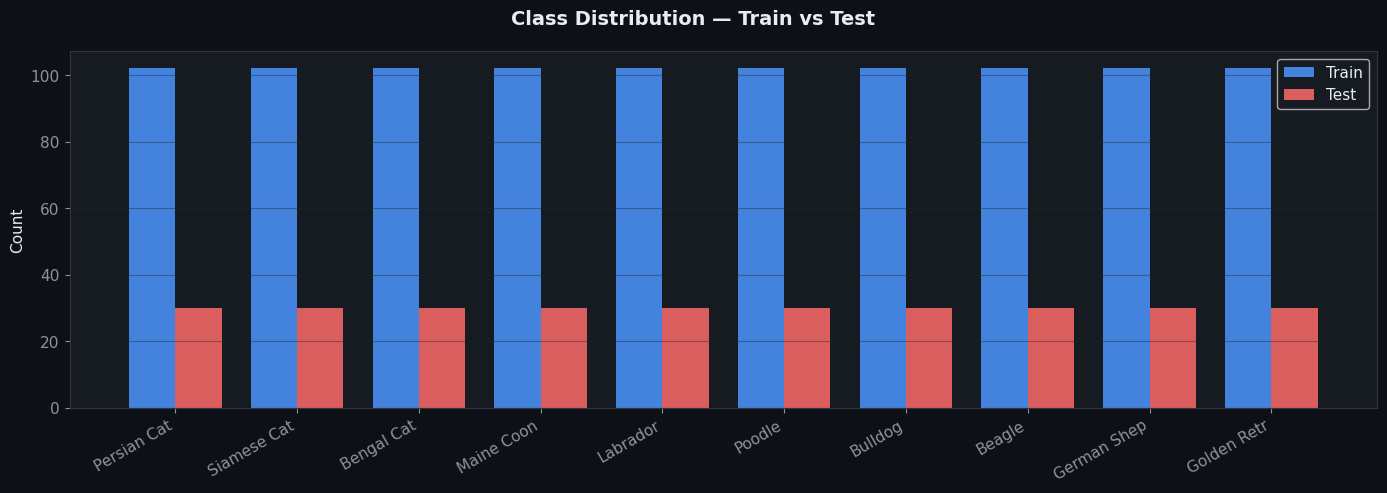

In [24]:
x_pos = np.arange(C)
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Class Distribution — Train vs Test', fontsize=14,
             fontweight='bold', color='#e6edf3')

ax.bar(x_pos - w/2, [np.sum(ytr==c) for c in range(C)], w,
       color='#4d96ff', alpha=0.85, label='Train')
ax.bar(x_pos + w/2, [np.sum(yte==c) for c in range(C)], w,
       color='#ff6b6b', alpha=0.85, label='Test')

ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

## 🧠 Section 4 — Neural Network Architecture

```
Input  3072   (32×32×3 flattened)
  │
  ▼
FC(512)  +  ReLU  +  Dropout(0.3)
  │
  ▼
FC(256)  +  ReLU  +  Dropout(0.3)
  │
  ▼
FC(10)   +  Softmax
```

**Optimiser:** Adam (β₁=0.9, β₂=0.999)  
**Loss:** Cross-Entropy  
**Weight init:** He initialisation

In [25]:
# ── Activation functions ─────────────────────────────────────────
def relu(z):       return np.maximum(0, z)
def relu_d(z):     return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - z.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

def cross_entropy(p, y):
    return -np.log(p[np.arange(len(y)), y] + 1e-9).mean()

def accuracy(p, y):
    return (p.argmax(1) == y).mean()

def one_hot(y, C):
    oh = np.zeros((len(y), C))
    oh[np.arange(len(y)), y] = 1
    return oh

print('✅ Activation functions defined')

✅ Activation functions defined


In [26]:
class PetNet:
    """
    3-layer fully-connected network.
    Input -> FC(h1) -> ReLU -> Dropout -> FC(h2) -> ReLU -> Dropout -> FC(n_cls) -> Softmax
    Optimised with Adam.
    """

    def __init__(self, in_dim, h1=512, h2=256, n_cls=10, seed=0):
        np.random.seed(seed)
        # He initialisation
        self.W1 = np.random.randn(in_dim, h1) * np.sqrt(2 / in_dim)
        self.b1 = np.zeros(h1)
        self.W2 = np.random.randn(h1, h2)     * np.sqrt(2 / h1)
        self.b2 = np.zeros(h2)
        self.W3 = np.random.randn(h2, n_cls)  * np.sqrt(2 / h2)
        self.b3 = np.zeros(n_cls)
        # Adam moments
        self.m = {k: np.zeros_like(v) for k, v in self.params().items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params().items()}
        self.t = 0

    def params(self):
        return {'W1': self.W1, 'b1': self.b1,
                'W2': self.W2, 'b2': self.b2,
                'W3': self.W3, 'b3': self.b3}

    # ── Forward pass ─────────────────────────────────────────────────
    def forward(self, X, drop=0.0, train=True):
        self.X   = X

        self.z1  = X @ self.W1 + self.b1
        self.a1  = relu(self.z1)
        self.d1  = ((np.random.rand(*self.a1.shape) > drop) / (1 - drop)
                    if train and drop > 0 else np.ones_like(self.a1))
        self.a1d = self.a1 * self.d1

        self.z2  = self.a1d @ self.W2 + self.b2
        self.a2  = relu(self.z2)
        self.d2  = ((np.random.rand(*self.a2.shape) > drop) / (1 - drop)
                    if train and drop > 0 else np.ones_like(self.a2))
        self.a2d = self.a2 * self.d2

        self.z3   = self.a2d @ self.W3 + self.b3
        self.prob = softmax(self.z3)
        return self.prob

    # ── Backward pass (backpropagation) ──────────────────────────────
    def backward(self, y):
        n   = len(y)
        dz3 = (self.prob - one_hot(y, self.prob.shape[1])) / n
        dW3 = self.a2d.T @ dz3;            db3 = dz3.sum(0)
        dz2 = (dz3 @ self.W3.T) * relu_d(self.z2) * self.d2
        dW2 = self.a1d.T @ dz2;            db2 = dz2.sum(0)
        dz1 = (dz2 @ self.W2.T) * relu_d(self.z1) * self.d1
        dW1 = self.X.T  @ dz1;             db1 = dz1.sum(0)
        return {'W1': dW1, 'b1': db1, 'W2': dW2,
                'b2': db2, 'W3': dW3, 'b3': db3}

    # ── Adam update ───────────────────────────────────────────────────
    def adam(self, grads, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for k, g in grads.items():
            self.m[k] = b1 * self.m[k] + (1 - b1) * g
            self.v[k] = b2 * self.v[k] + (1 - b2) * g ** 2
            mh = self.m[k] / (1 - b1 ** self.t)
            vh = self.v[k] / (1 - b2 ** self.t)
            setattr(self, k, getattr(self, k) - lr * mh / (np.sqrt(vh) + eps))


print('✅ PetNet class defined')

✅ PetNet class defined


### 🔢 Preprocess — Flatten & Standardise

In [27]:
# Compute mean & std from training set only (prevents data leakage)
mu  = Xtr.reshape(len(Xtr), -1).mean(0)
std = Xtr.reshape(len(Xtr), -1).std(0) + 1e-8

flat = lambda Z: (Z.reshape(len(Z), -1) - mu) / std

Xtr_f = flat(Xtr)
Xvl_f = flat(Xvl)
Xte_f = flat(Xte)

print(f'Flattened shape : {Xtr_f.shape}')
print(f'Mean (approx)   : {Xtr_f.mean():.4f}')
print(f'Std  (approx)   : {Xtr_f.std():.4f}')

Flattened shape : (1020, 3072)
Mean (approx)   : 0.0000
Std  (approx)   : 1.0000


## 🚀 Section 5 — Training Loop

- **Mini-batch Adam** with batch size 64  
- **Dropout 0.3** during training  
- **Best-model checkpointing** (saves weights with lowest val loss)  
- Logs loss & accuracy every epoch

In [28]:
def train(model, Xtr, ytr, Xvl, yvl,
          epochs=60, bs=64, lr=5e-4, drop=0.3):

    history = {'tl': [], 'vl': [], 'ta': [], 'va': []}
    best_vl, best_w = np.inf, None

    for ep in range(1, epochs + 1):
        # Shuffle training data
        idx = np.random.permutation(len(ytr))
        Xs, ys = Xtr[idx], ytr[idx]

        # Mini-batch updates
        for s in range(0, len(ytr), bs):
            Xb, yb = Xs[s:s+bs], ys[s:s+bs]
            model.forward(Xb, drop=drop, train=True)
            model.adam(model.backward(yb), lr=lr)

        # Epoch metrics (no dropout)
        pt = model.forward(Xtr, train=False)
        pv = model.forward(Xvl, train=False)

        tl, vl = cross_entropy(pt, ytr), cross_entropy(pv, yvl)
        ta, va = accuracy(pt, ytr),      accuracy(pv, yvl)

        history['tl'].append(tl); history['vl'].append(vl)
        history['ta'].append(ta); history['va'].append(va)

        # Save best weights
        if vl < best_vl:
            best_vl = vl
            best_w  = {k: v.copy() for k, v in model.params().items()}

        print(f'  Epoch {ep:3d}/{epochs}  '
              f'loss {tl:.4f}→{vl:.4f}  '
              f'acc {ta*100:.1f}%→{va*100:.1f}%')

    # Restore best weights
    for k, v in best_w.items():
        setattr(model, k, v)

    return history


print('✅ Training function defined')

✅ Training function defined


In [29]:
# Build and train the model
model = PetNet(in_dim=Xtr_f.shape[1], h1=512, h2=256,
               n_cls=C, seed=42)

print(f'Architecture: {Xtr_f.shape[1]} → 512 → 256 → {C}')
total_params = (Xtr_f.shape[1]*512 + 512 +
                512*256 + 256 +
                256*C   + C)
print(f'Total params: {total_params:,}')
print()

history = train(model, Xtr_f, ytr, Xvl_f, yvl,
                epochs=60, bs=64, lr=5e-4, drop=0.3)

Architecture: 3072 → 512 → 256 → 10
Total params: 1,707,274

  Epoch   1/60  loss 1.0732→1.1129  acc 61.6%→60.6%
  Epoch   2/60  loss 0.2890→0.3504  acc 92.2%→85.6%
  Epoch   3/60  loss 0.2695→0.3137  acc 89.2%→87.8%
  Epoch   4/60  loss 0.1314→0.1854  acc 93.4%→88.3%
  Epoch   5/60  loss 0.1081→0.1447  acc 97.3%→93.3%
  Epoch   6/60  loss 0.1128→0.1611  acc 91.4%→90.0%
  Epoch   7/60  loss 0.1853→0.2303  acc 90.0%→90.0%
  Epoch   8/60  loss 0.1154→0.1345  acc 91.0%→91.1%
  Epoch   9/60  loss 0.1041→0.1454  acc 91.3%→90.6%
  Epoch  10/60  loss 0.0917→0.1223  acc 95.7%→91.1%
  Epoch  11/60  loss 0.0679→0.1063  acc 97.6%→91.7%
  Epoch  12/60  loss 0.0430→0.0778  acc 99.9%→98.3%
  Epoch  13/60  loss 0.0332→0.0869  acc 99.9%→93.9%
  Epoch  14/60  loss 0.0282→0.0815  acc 100.0%→98.9%
  Epoch  15/60  loss 0.0262→0.0891  acc 100.0%→93.3%
  Epoch  16/60  loss 0.0410→0.1263  acc 99.6%→91.1%
  Epoch  17/60  loss 0.0261→0.0744  acc 100.0%→99.4%
  Epoch  18/60  loss 0.0138→0.0627  acc 100.0%→98.3%

## 📊 Section 6 — Evaluation & Results

In [30]:
# Final evaluation on held-out test set
probs = model.forward(Xte_f, train=False)
ypred = probs.argmax(1)

test_loss = cross_entropy(probs, yte)
test_acc  = accuracy(probs, yte)

print('=' * 55)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print('=' * 55)
print()
print(classification_report(yte, ypred, target_names=CLASS_NAMES))

  Test Loss     : 0.0280
  Test Accuracy : 98.33%

              precision    recall  f1-score   support

 Persian Cat       1.00      0.83      0.91        30
 Siamese Cat       1.00      1.00      1.00        30
  Bengal Cat       1.00      1.00      1.00        30
  Maine Coon       1.00      1.00      1.00        30
    Labrador       1.00      1.00      1.00        30
      Poodle       0.86      1.00      0.92        30
     Bulldog       1.00      1.00      1.00        30
      Beagle       1.00      1.00      1.00        30
 German Shep       1.00      1.00      1.00        30
 Golden Retr       1.00      1.00      1.00        30

    accuracy                           0.98       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.98      0.98       300



## 📈 Section 7 — Plots

### Training Curves — Loss & Accuracy

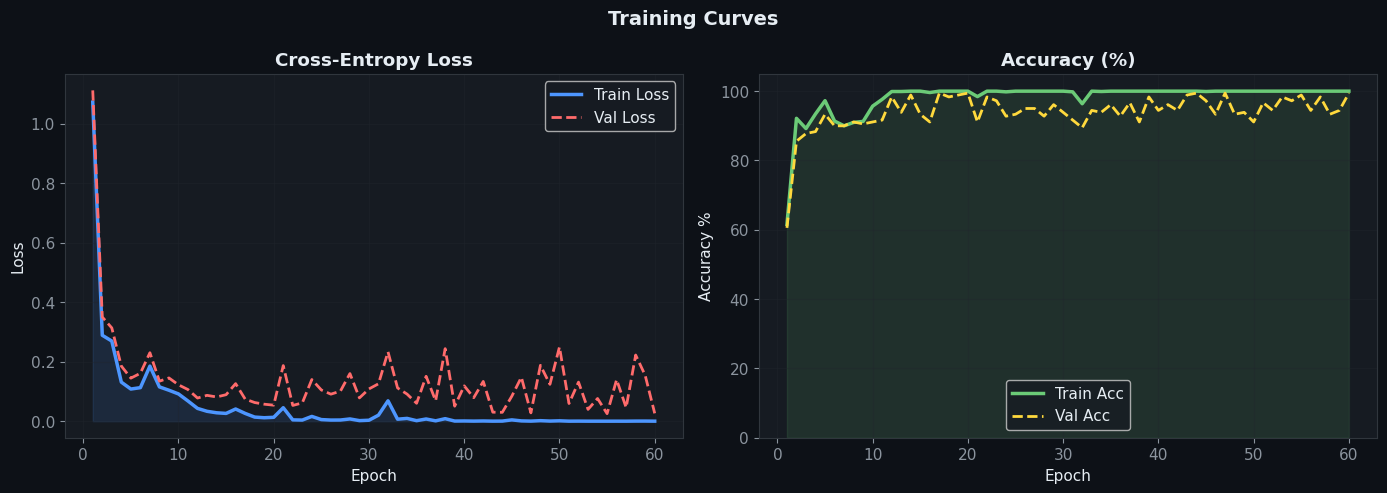

In [31]:
ep = np.arange(1, len(history['tl']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves', fontsize=14, fontweight='bold', color='#e6edf3')

# Loss
axes[0].plot(ep, history['tl'], color='#4d96ff', lw=2.5, label='Train Loss')
axes[0].plot(ep, history['vl'], color='#ff6b6b', lw=2,   ls='--', label='Val Loss')
axes[0].fill_between(ep, history['tl'], alpha=0.12, color='#4d96ff')
axes[0].set_title('Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(ep, [a*100 for a in history['ta']], color='#6bcb77', lw=2.5, label='Train Acc')
axes[1].plot(ep, [a*100 for a in history['va']], color='#ffd93d', lw=2,   ls='--', label='Val Acc')
axes[1].fill_between(ep, [a*100 for a in history['ta']], alpha=0.12, color='#6bcb77')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy %')
axes[1].set_ylim(0, 105); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()